In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

In [21]:
df=pd.read_csv('new.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [22]:
df['TotalSpend']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']
features=['Income','MntWines','MntMeatProducts','TotalSpend']
df[features]=df[features].fillna(df[features].mean())
X=df[features]

In [23]:
for col in features:
    Q1=X[col].quantile(0.25)
    Q3=X[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    mask=(X[col]>=lower)&(X[col]<=upper)
    X=X[mask]

In [24]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [25]:
inertias=[]
scores=[]
k_values=range(2,10)

best_k=2
best_score=-1
for k in k_values:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    score=silhouette_score(X_scaled,labels)
    scores.append(score)
    print("k=",k,"silhouette=",score)
    if score>best_score:
        best_score=score
        best_k=k
print("\nOptimal k:",best_k)
print("Best Silhouette Score:",best_score)

k= 2 silhouette= 0.5784269873089489
k= 3 silhouette= 0.47596815168646095
k= 4 silhouette= 0.4304672366099639
k= 5 silhouette= 0.3813479846345617
k= 6 silhouette= 0.372780847951846
k= 7 silhouette= 0.35241504451414263
k= 8 silhouette= 0.35228894805410266
k= 9 silhouette= 0.3393769722244412

Optimal k: 2
Best Silhouette Score: 0.5784269873089489


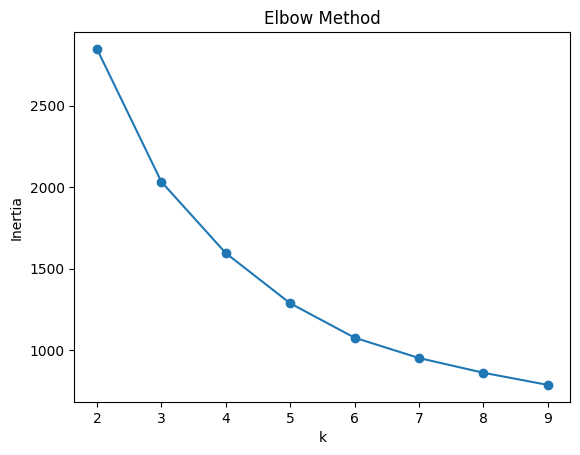

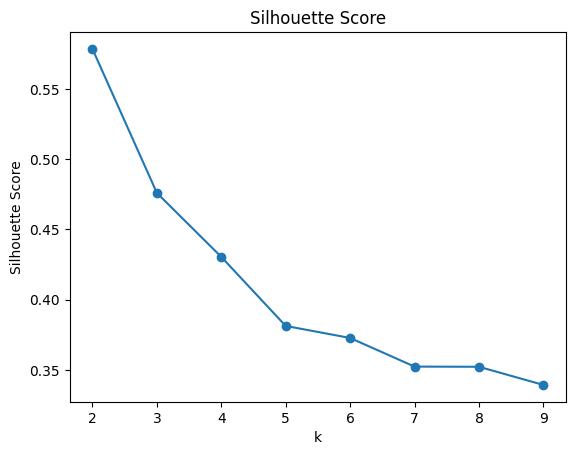

In [26]:
plt.plot(k_values,inertias,marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
plt.plot(k_values,scores,marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [27]:
kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=10)
kmeans_labels=kmeans.fit_predict(X_scaled)

In [28]:
hc=AgglomerativeClustering(n_clusters=3)
hc_labels=hc.fit_predict(X_scaled)

In [31]:
df=df.loc[X.index]
df['KMeans_Cluster']=kmeans_labels
df['HC_Cluster']=hc_labels

In [30]:
X_knn=X_scaled
y_knn=kmeans_labels
X_train,X_test,y_train,y_test=train_test_split(X_knn,y_knn,test_size=0.2,random_state=42)
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print("KNN Accuracy:",acc)

KNN Accuracy: 0.9900249376558603
